# 2) Choose Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import timeit
import warnings
import sklearn
warnings.filterwarnings("ignore")

## 0) Load 

In [2]:
def loadData():
    # title,img_url,description,ratings,n_votes,is_adult,production_year,runtime,genres,release_year,studio,img_embeddings,text_embeddings

    X1 = pd.read_csv("X1.csv")
    X2 = pd.read_csv("X2.csv")
    Y1 = pd.read_csv("Y1.csv", header=None, names=['revenue'])

    split = X1['genres'].str.split(',')
    X1['genres']=split
    split = X2['genres'].str.split(',')
    X2['genres']=split


    X1["img_embeddings_array"] =  [ast.literal_eval(X1['img_embeddings'][i]) for i in range(len(X1))]
    X1["text_embeddings_array"] = [ast.literal_eval(X1['text_embeddings'][i]) for i in range(len(X1))]

    X2 ["img_embeddings_array"] =  [ast.literal_eval(X2['img_embeddings'][i]) for i in range(len(X2))]
    X2 ["text_embeddings_array"] = [ast.literal_eval(X2['text_embeddings'][i]) for i in range(len(X2))]


    Y1["log_revenue"] = np.log(Y1["revenue"])

    X1["exp_ratings"] = np.exp(X1["ratings"])
    X1["log_ratings"] = np.log(X1["ratings"])
    X1["log_n_votes"] = np.log(X1["n_votes"])



    # genres management

    list_genres = np.unique(np.concatenate(X1['genres']))


    for genre in list_genres:
        X1[genre] = [int(genre in X1['genres'][i]) for i in range(len(X1['genres']))]

    for genre in list_genres:
        X2[genre] = [int(genre in X2['genres'][i]) for i in range(len(X2['genres']))]


    liste_variables = []
    for genre in list_genres:
        a = np.sum(X1[genre])
        liste_variables.append(a)


    dic = {}
    j = 0
    for genre in list_genres:
        dic[genre] = liste_variables[j]
        j+=1


    X1['genre'] = [sum([dic[i]for i in j])/len(j) for j in X1['genres']]


    list_genres = ['genre'] + list(list_genres) 



    # studios management

    X_dum = pd.get_dummies(X1['studio'])

    liste_variables = []
    for i in X_dum:
        a = np.sum(X_dum[i])
        liste_variables.append(a)


    dic = {}
    j = 0
    for i in X_dum:
        dic[i] = liste_variables[j]
        j+=1


    X1['std'] = [dic[i] for i in X1['studio']]


    # img embeddigs management

    A = list(X1["img_embeddings_array"].copy())
    A = np.asarray(A)

    U , S, Vt = np.linalg.svd(A)
    nb_compo_img = len(S)

    for i in range(len(S)):
        X1["img"+str(i)] = U[::][i]*S[i]



    # text embeddigs management

    A = list(X1["text_embeddings_array"].copy())
    A = np.asarray(A)

    U, S, Vt = np.linalg.svd(A)
    nb_compo_text = len(S)

    for i in range(len(S)):
        X1["text"+str(i)] =U[::][i] *S[i]

    genre = list_genres

    img = list(np.array(range(nb_compo_img), str))
    for i in range(len(img)):
        img[i] = "img"+img[i]


    text = list(np.array(range(nb_compo_text), str))
    for i in range(len(text)):
        text[i] = "text"+text[i]


    variable_base = ["exp_ratings", "ratings", "log_ratings",  "n_votes", "log_n_votes",  "production_year", "release_year", "std", 'genre', "runtime" ] 
    variables_svd =  img + text
    variable_genre = genre
    liste_variables = variable_base+variables_svd+variable_genre
    liste_targets = [ "log_revenue", "revenue"]


    X = X1[liste_variables]
    Y = Y1[liste_targets]

    return X, Y, variable_base, variables_svd, variable_genre , liste_targets

In [ ]:
X, y, variable_base, variables_svd, variable_genre, liste_targets = loadData()

## 1) Clean Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.9)

print(X_train.shape)
print(X_test.shape)
print(X.shape)

(3186, 2854)
(354, 2854)
(3540, 2854)


In [ ]:
# We remove features that are too small and those where the data are too noisy
EPS = 100

selected_svd = []

for var in variables_svd:
    if np.sum(np.abs(X_train[var])) < EPS:
        X_train.drop(var, axis=1, inplace=True)
        X_test.drop(var, axis=1, inplace=True)
    else :
        selected_svd.append(var)

X_train.head()

,exp_ratings,ratings,log_ratings,n_votes,log_n_votes,production_year,release_year,std,genre,runtime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western,\N
1580,1211.967074,7.1,1.960095,116587.0,11.666393,1995,1995.0,24,965.500000,94,...,0,0,1,0,0,0,0,0,0,0
3491,365.037468,5.9,1.774952,803.0,6.688355,1984,1984.0,184,787.333333,109,...,0,0,0,0,0,0,1,0,0,0
2599,330.299560,5.8,1.757858,10786.0,9.286004,2007,2008.0,95,1873.000000,97,...,0,0,0,0,0,0,0,0,0,0
415,1096.633158,7.0,1.945910,1832.0,7.513164,1997,1998.0,46,1120.000000,75,...,0,0,0,0,0,0,0,0,0,0
2290,492.749041,6.2,1.824549,21.0,3.044522,1997,2000.0,1,194.000000,80,...,0,0,0,0,0,0,0,0,0,0


**Runtime : replace //N with mean substitution**

In [ ]:
#replace //N values with mean substitution

Rt_train = X_train['runtime']
nbNan =0

for ind in Rt_train.index:
    value = Rt_train[ind]
    nbNan += (value=='\\N')
    if( value=='\\N'):
        Rt_train = Rt_train.drop(ind)

print("The percentage of /N in runtime is : ", (nbNan/len(X_train))*100)
mean = np.mean(np.array(Rt_train, dtype=float))
print("Runtime average is (in minutes)", mean)



Rt_train = X_train['runtime']
for ind in Rt_train.index:
    if( Rt_train[ind]=='\\N'):
        Rt_train[ind] = mean

Rt_test = X_test['runtime']
for ind in Rt_test.index:
    if( Rt_test[ind]=='\\N'):
        Rt_test[ind] = mean



Rt_train = pd.DataFrame(Rt_train, dtype=float)
Rt_test = pd.DataFrame(Rt_test, dtype=float)



X_train['runtime']=Rt_train
X_train['log_runtime'] = np.log(Rt_train)

X_test['runtime']=Rt_test
X_test['log_runtime'] = np.log(Rt_test)

The percentage of /N in runtime is :  7.689893283113622
Runtime average is (in minutes) 91.9534172050323


## 2) Training models 

In [ ]:
X_train_models, X_test_models, y_train_models, y_test_models = train_test_split(X_train, y_train, random_state=42, train_size=0.9)
print("Number of features in X_train_models : ", X_train_models.shape[1])
print("Number of features in X_test_models : ",X_test_models.shape[1])

Number of features in X_train_models :  1708
Number of features in X_test_models :  1708


### a) Linear Models

#### 0. Mean 

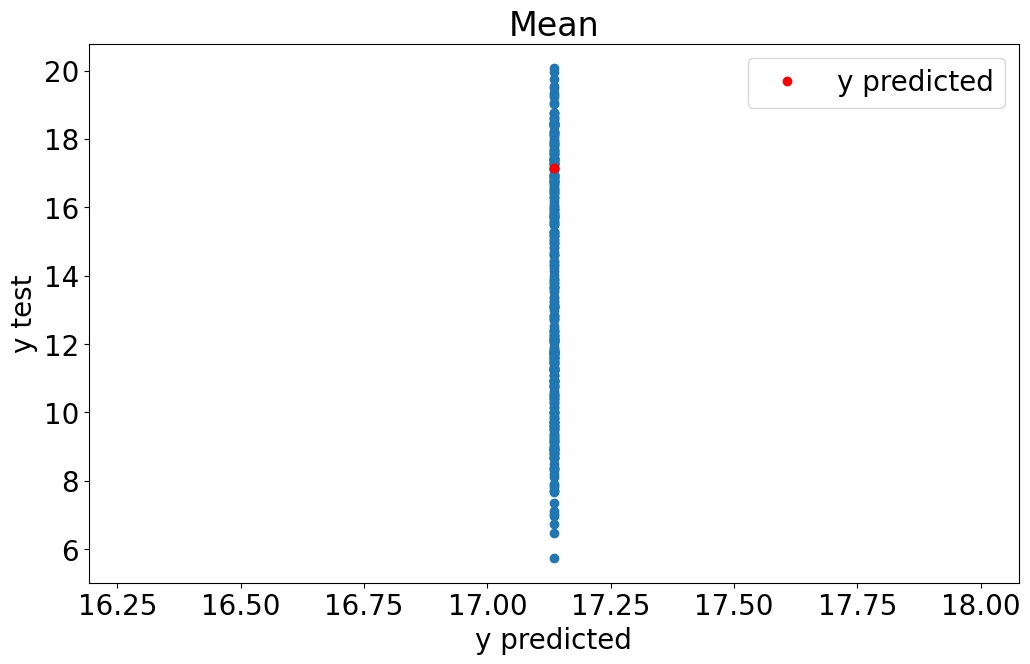

Mean squared error: 61.47 Millions
R squared score: -1.18


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_mean = y_train_models.copy()
y_test_mean = y_test_models.copy() 

y_train_mean = y_train_mean["revenue"]
y_test_mean = y_test_mean["revenue"]


mean = np.mean(y_train_mean)
y_predict = np.ones(len(y_test_mean))*mean

y_test1= y_test_mean
y_predict1 = y_predict

y_test_mean = np.log(y_test_mean)
y_predict = np.log(y_predict)


plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('Mean')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(y_predict,y_test_mean,'o')
plt.plot(np.linspace(np.min(y_predict),np.max(y_predict),2),np.linspace(np.min(y_predict),np.max(y_predict),2), 'o', label="y predicted",color="red")
plt.legend()
plt.show()



# The mean squared error
print("Mean squared error: %.2f Millions" % (np.sqrt(mean_squared_error(y_test1,y_predict1))/1000000))
print("R squared score: %.2f" % (r2_score(y_test_mean, y_predict)))


#### 1. Linear Regressor

In [ ]:
X_train_lin = X_train_models.copy()
X_test_lin =  X_test_models.copy()
y_train_lin = y_train_models.copy()
y_test_lin = y_test_models.copy() 


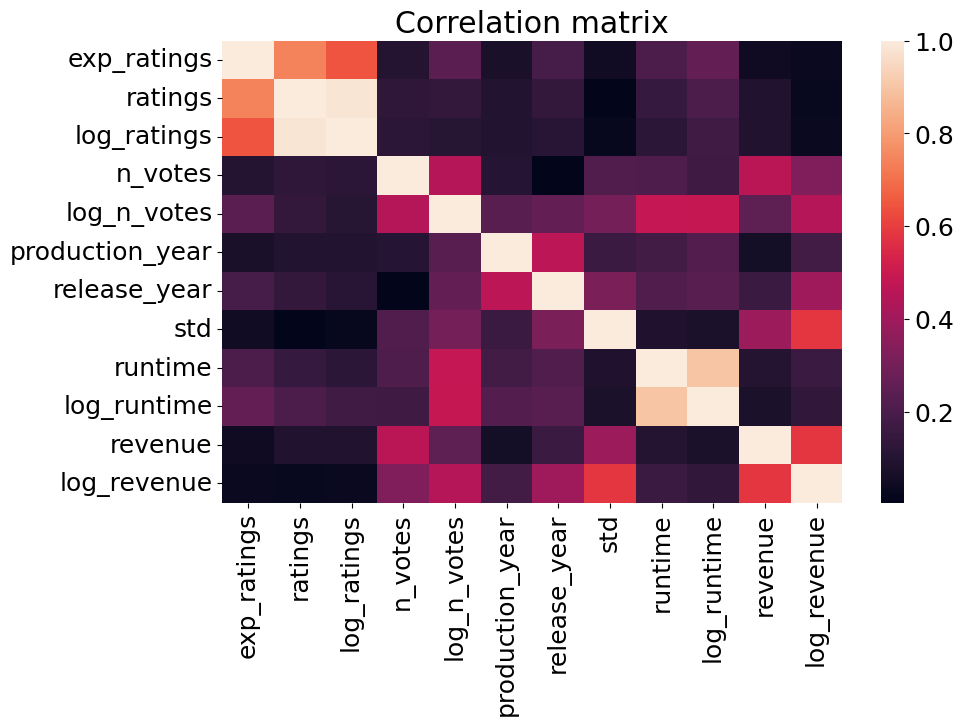

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Xy_corr_var_sp = pd.concat([X_train_lin[["exp_ratings","ratings", "log_ratings", "n_votes", "log_n_votes",  "production_year", "release_year", "std", "runtime", "log_runtime"]] , y_train_lin[["revenue", "log_revenue"]]], axis=1)

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
sns.heatmap(np.abs(Xy_corr_var_sp.corr()))
plt.title('Correlation matrix')
plt.show()

selected_svd
# à runner qu'une fois
# We choose to keep the logarithm of the revenue
y_train_lin = y_train_lin["log_revenue"]
y_test_lin = y_test_lin["log_revenue"]

In [ ]:
# We choose to keep the features : "log_ratings", "log_n_votes", "production_year", "release_year", "std", "runtime", "text_embedding", "image_embedding", "studio" and "genre"

#X_train = X_train.drop("exp_ratings", axis=1)
X_train_lin = X_train_lin.drop("ratings", axis=1)
X_train_lin = X_train_lin.drop("n_votes", axis=1)
X_train_lin = X_train_lin.drop("log_runtime", axis=1)

X_test_lin = X_test_lin.drop("ratings", axis=1)
X_test_lin = X_test_lin.drop("n_votes", axis=1)
X_test_lin = X_test_lin.drop("log_runtime", axis=1)

print("Dimension of X_train_lin : ", X_train_lin.shape)

Dimension of X_train_lin :  (2867, 1705)


In [ ]:
#select K best

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.preprocessing import StandardScaler
from scipy import stats

def select_features_correlation(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(f_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(f_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs

def find_k_linear(X_train_f, X_test_f, y_train_f, y_test_f):
    coef = []
    error = []

    for k in np.arange((X_train_f.shape[1])/8, 1, -1, dtype=int):
        
        X_train_f, X_test_f, _ = select_features_correlation(X_train_f, y_train_f, X_test_f, k)
        
        scaler = StandardScaler()
        scaler.fit(X_train_f)
        X_train_s = scaler.transform(X_train_f)
        X_test_s = scaler.transform(X_test_f)

        y_train_s =y_train_f[(np.abs(stats.zscore(X_train_s))<3 ).all(axis=1)]
        X_train_s = X_train_s[(np.abs(stats.zscore(X_train_s))<3).all(axis=1)]

        regressor = LinearRegression()
        regressor.fit(X_train_s, y_train_s)
        y_predict = regressor.predict(X_test_s)
        
        try: mse = mean_squared_error(np.exp(y_test_f),np.exp(y_predict))
        except: mse = np.nan
        error.append(mse)
        coef.append(k)
        
    maximum = max(x for x in error if str(x) != 'nan')
   
    for i in range(len(error)):
        if (np.isnan(error[i])):
            error[i] = maximum
            
    plt.rc("font", size=18)
    plt.figure(figsize=(10,6))
    plt.plot(coef, np.sqrt(error)/1000000)
    plt.xlabel("Nber of best features")
    plt.ylabel("Mean square error")
    plt.ylim([0, 200])
    plt.title("Evolution of error according to the number of best features selected in linear model")
    plt.show()

    tmp = min(error)
    print("The minimum mean square error obtaines is :", np.sqrt(tmp)/1000000)
    k = error.index(tmp)
    k = coef[k]
    return k

In [ ]:
# Tuning split to choose the best k (number of best features)

X_train_lin_tun, X_test_lin_tun, y_train_lin_tun, y_test_lin_tun = train_test_split(X_train_lin, y_train_lin, random_state=42)

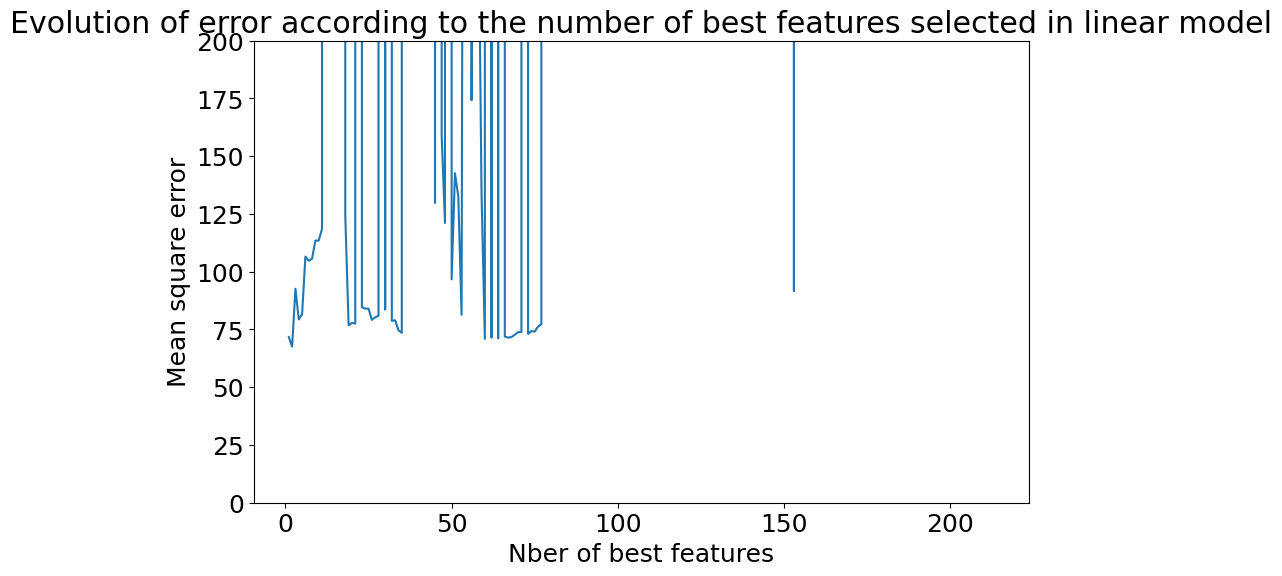

The minimum mean square error obtaines is : 67.56488649289382
We choose k_lin =  2


In [ ]:
# Once we have found k_lin, we re-use X_train_lin

k_lin = find_k_linear(X_train_lin_tun, X_test_lin_tun, y_train_lin_tun, y_test_lin_tun)
print("We choose k_lin = ",k_lin)
X_train_lin, X_test_lin, fs = select_features_correlation(X_train_lin, y_train_lin, X_test_lin, k_lin)

Coefficients: [0.36635015 0.02949537]
Mean squared error: 61.39 Millions
R squared score: 0.38


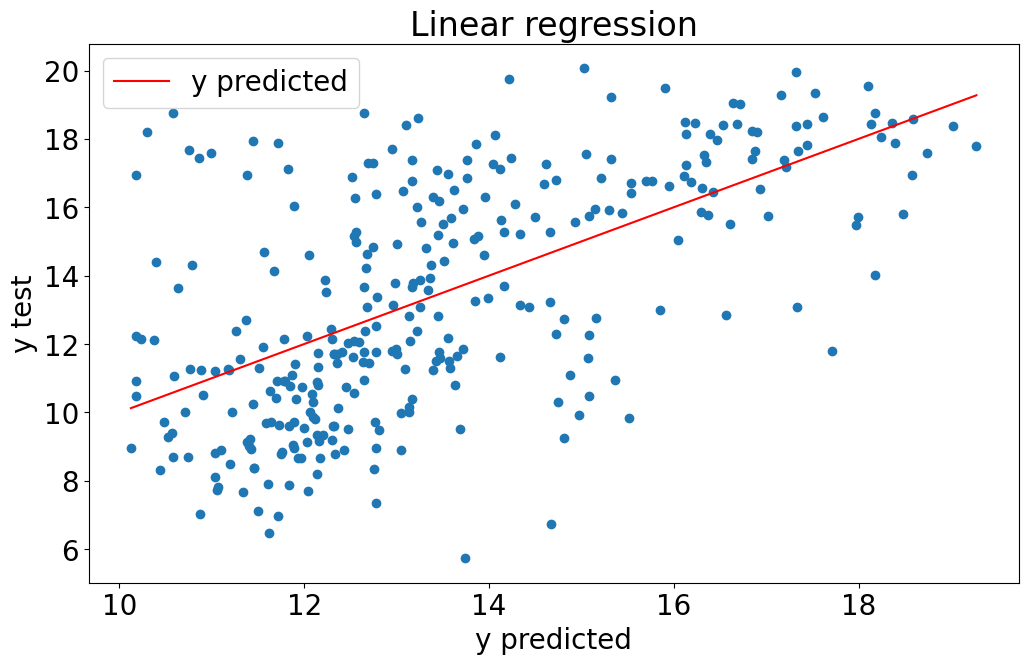

In [ ]:
# Linear regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 
regressor = LinearRegression()
regressor.fit(X_train_lin, y_train_lin)
y_predict = regressor.predict(X_test_lin)

plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('Linear regression')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(y_predict,y_test_lin,'o')
plt.plot(np.linspace(np.min(y_predict),np.max(y_predict),2),np.linspace(np.min(y_predict),np.max(y_predict),2), label="y predicted",color="red")
plt.legend()

y_test1= np.exp(y_test_lin)
y_predict1 = np.exp(y_predict)


# The coefficients
print("Coefficients:", regressor.coef_)
# The mean squared error
print("Mean squared error: %.2f Millions" % (np.sqrt(mean_squared_error(y_test1,y_predict1))/1000000))
# The coefficient of determination: 1 is perfect prediction
print("R squared score: %.2f" % (r2_score(y_test_lin, y_predict)))




### b) Non Linear Models


#### 1. MLP

In [ ]:
X_train_MLP = X_train_models.copy()
X_test_MLP =  X_test_models.copy()
y_train_MLP = y_train_models.copy()
y_test_MLP= y_test_models.copy() 


In [ ]:
# We keek the logarithm of revenue
y_train_MLP = y_train_MLP["log_revenue"]
y_test_MLP = y_test_MLP["log_revenue"]

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train_MLP)
X_train_MLP = scaler.transform(X_train_MLP)
X_test_MLP = scaler.transform(X_test_MLP)

In [ ]:
#select K best
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from matplotlib import pyplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neural_network import MLPRegressor
from sklearn import metrics

def Mutual_info(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(mutual_info_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(mutual_info_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs


def find_k_Nonlinear(X_train_f, X_test_f, y_train_f, y_test_f):
    coef = []
    error = []
    liste = np.array([800, 600, 400, 300, 200, 50, 10, 5, 2])

    for k in liste:
        print(k)
        X_train_f, X_test_f, fs = Mutual_info(X_train_f, y_train_f, X_test_f, k)

        scaler = StandardScaler()
        scaler.fit(X_train_f)
        X_train_s = scaler.transform(X_train_f)
        X_test_s = scaler.transform(X_test_f)
        # y_train_s =y_train_f[(np.abs(stats.zscore(X_train_s))<3 ).all(axis=1)]
        y_train_s = y_train_f
        # X_train_s = X_train_s[(np.abs(stats.zscore(X_train_s))<3).all(axis=1)]

        regressor = MLPRegressor(random_state=42, max_iter=20000, activation= 'logistic', alpha= 0.0001, hidden_layer_sizes= (25,25,25), learning_rate= 'constant', solver= 'adam')
        regressor.fit(X_train_s, y_train_s)

        plt.plot(regressor.loss_curve_)
        plt.show()

        y_predict = regressor.predict(X_test_s)
        error.append(metrics.mean_squared_error(np.exp(y_test_f),np.exp(y_predict)))
        coef.append(k)
        print("R squared score: ", regressor.score(X_test_f, y_test_f))

        
        
    plt.rc("font", size=18)
    plt.figure(figsize=(10,6))
    plt.plot(coef, np.sqrt(error)/1000000)
    plt.xlabel("Nber of best features")
    plt.ylabel("Mean square error")
    plt.ylim([0, 100])
    plt.title("Evolution of error according to the number of best features selected")
    plt.show()

    tmp = min(error)
    print("The minimum mean square error obtaines is :", np.sqrt(tmp)/1000000)
    k = error.index(tmp)
    k = coef[k]
    return k

In [ ]:
#  Tuning split to choose the best k (number of best features)

X_train_MLP_tun, X_test_MLP_tun, y_train_MLP_tun, y_test_MLP_tun = train_test_split(X_train_MLP, y_train_MLP, random_state=42)

800


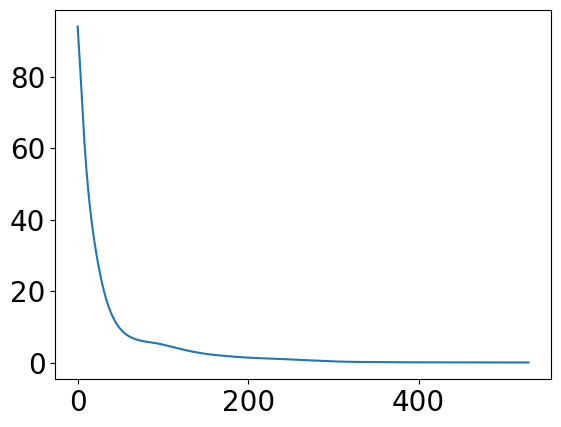

R squared score:  -0.05481806058319938
600


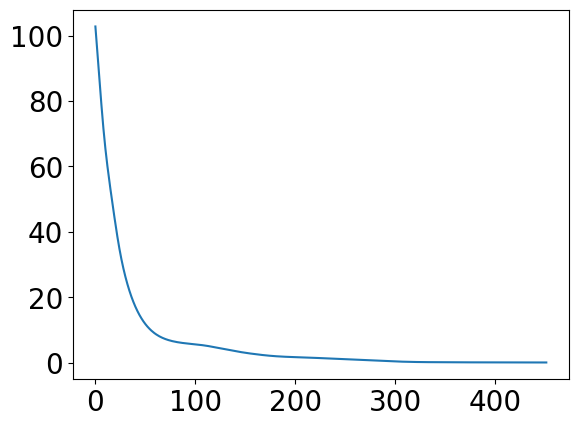

R squared score:  0.10354227380988801
400


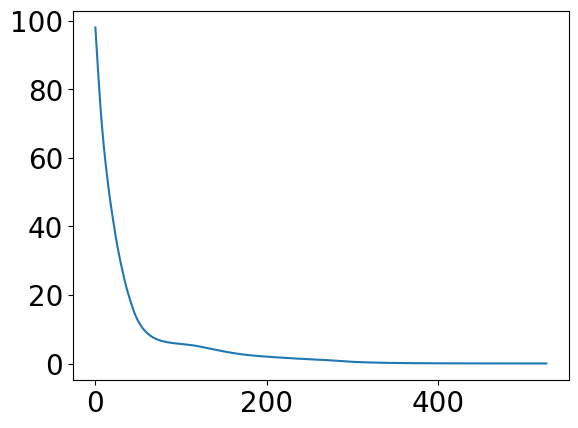

R squared score:  0.12660409907999404
300


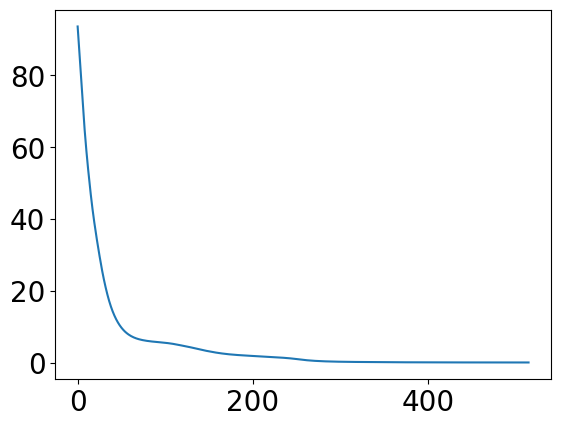

R squared score:  0.09555345238742896
200


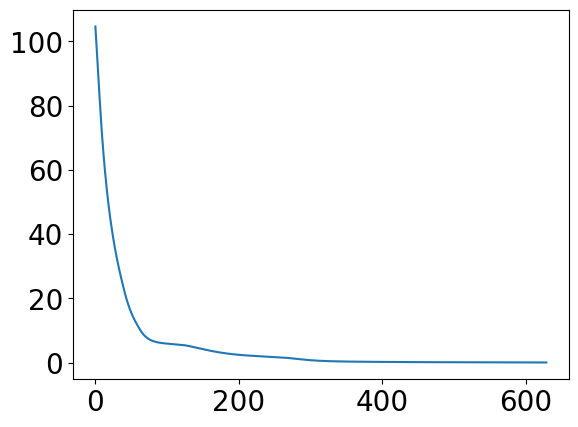

R squared score:  0.12065024202573627
50


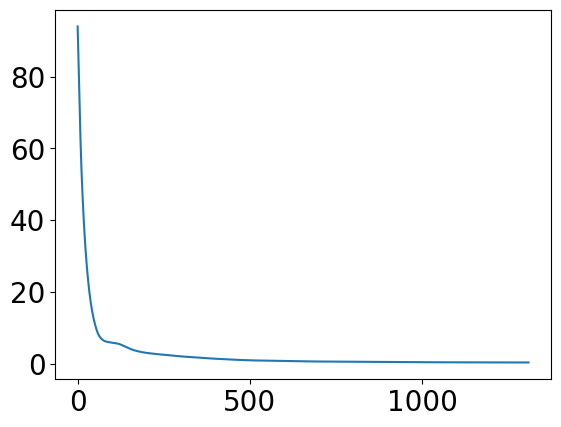

R squared score:  -0.0024971232151764777
10


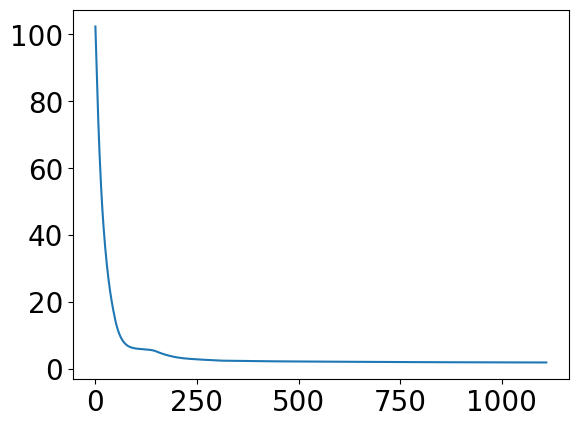

R squared score:  0.5470045321608505
5


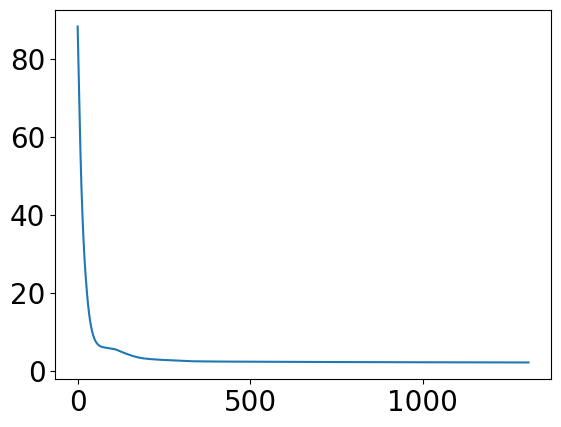

R squared score:  0.5566386298270252
2


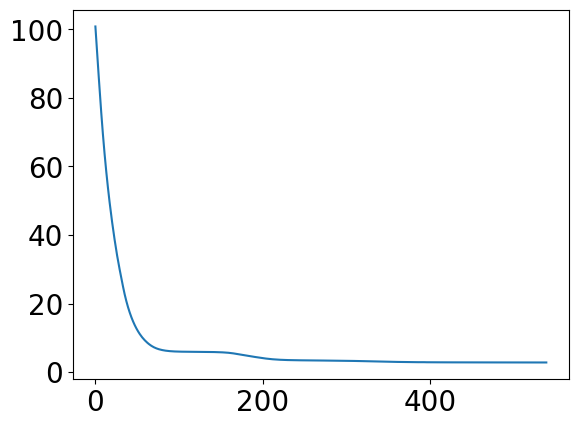

R squared score:  0.4685591993282988


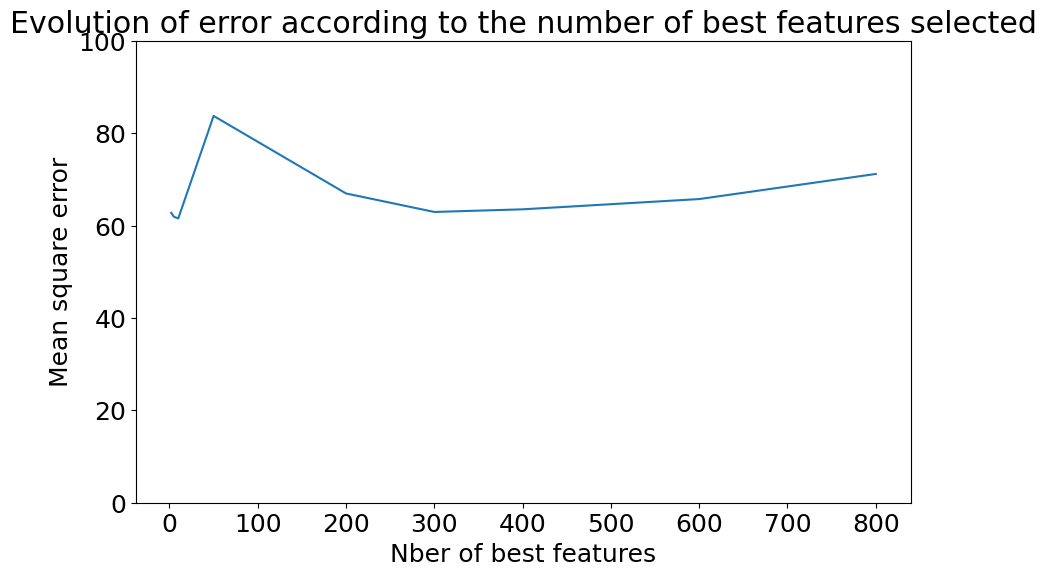

The minimum mean square error obtaines is : 61.53837363642321
We choose k_Nonlin =  10


In [ ]:
# Non linear
k_MLP = find_k_Nonlinear(X_train_MLP_tun, X_test_MLP_tun, y_train_MLP_tun, y_test_MLP_tun)
print("We choose k_Nonlin = ",k_MLP)
X_train_MLP, X_test_MLP, fs = Mutual_info(X_train_MLP, y_train_MLP, X_test_MLP, 200)


In [ ]:
# Find the best number of neurons

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, KFold
mlp_regressor = MLPRegressor(random_state=42)
param_list = {
    'hidden_layer_sizes': [(25, 25, 25), (50, 50, 50), (10,10,10)],
    'activation': ['logistic'],
    'solver': ['adam'],
    'alpha': [0.0001],
    'learning_rate': ['constant'],
    'max_iter': [20000],
    'random_state':[42]
}
cv = KFold(n_splits=2, random_state=42, shuffle=True)
gscv = GridSearchCV(mlp_regressor,param_list, scoring='r2', cv=cv)
gscv.fit(X_train_MLP_tun, np.ravel(y_train_MLP_tun))
print(gscv.best_params_)

{'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (25, 25, 25), 'learning_rate': 'constant', 'max_iter': 20000, 'random_state': 42, 'solver': 'adam'}


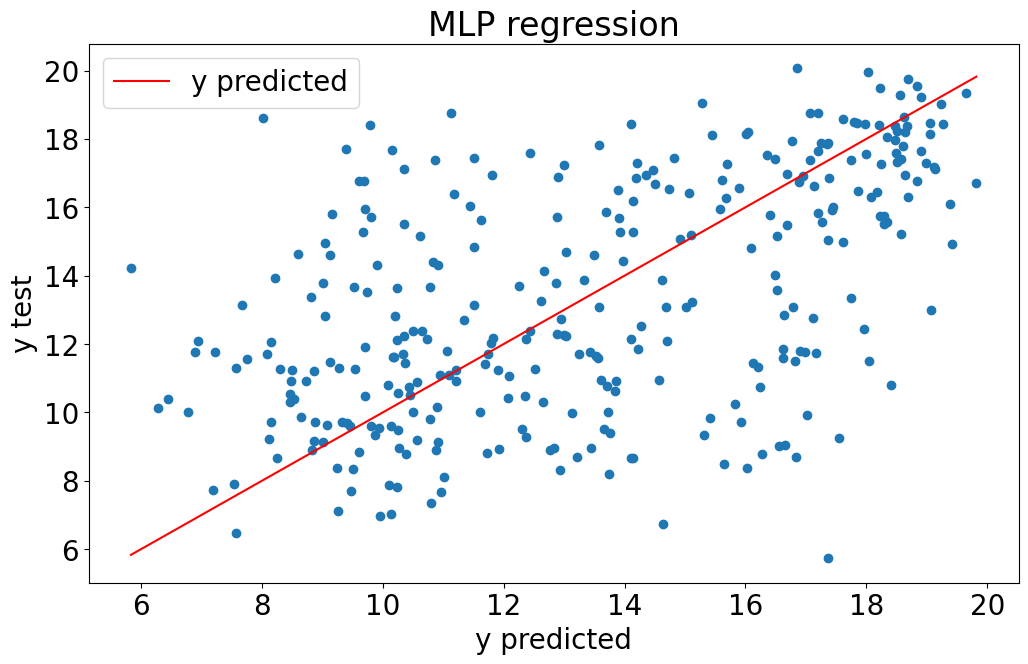

Mean Squared Error in Millions 65.08505746086767
R squared score:  0.0336735098917923


In [ ]:
# Regression
from sklearn.neural_network import MLPRegressor
from sklearn import metrics


mlp_regressor = MLPRegressor(**gscv.best_params_)
mlp_regressor.set_params(max_iter=20000)

mlp_regressor.fit(X_train_MLP, np.ravel(y_train_MLP))
y_predict = mlp_regressor.predict(X_test_MLP)

plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('MLP regression')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(y_predict,y_test_MLP, "o")
plt.plot(np.linspace(np.min(y_predict),np.max(y_predict),2),np.linspace(np.min(y_predict),np.max(y_predict),2), label="y predicted", color="red")
plt.legend()
plt.show()

y_test1= np.exp(y_test_MLP)
y_predict1 = np.exp(y_predict)
 
print("Mean Squared Error in Millions", np.sqrt(metrics.mean_squared_error(y_test1, y_predict1))/1000000) 
print("R squared score: ", mlp_regressor.score(X_test_MLP, y_test_MLP))




In [ ]:
#plt.plot(mlp_regressor.loss_curve_)


#### 2. Knn regression

In [ ]:
X_train_KNN = X_train_models.copy()
X_test_KNN =  X_test_models.copy()
y_train_KNN = y_train_models.copy()
y_test_KNN = y_test_models.copy() 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_KNN)
X_train_KNN = scaler.transform(X_train_KNN)
X_test_KNN = scaler.transform(X_test_KNN)

In [ ]:
y_train_KNN = y_train_KNN["log_revenue"]
y_test_KNN = y_test_KNN["log_revenue"]

R squared score:  -0.4586378649373728


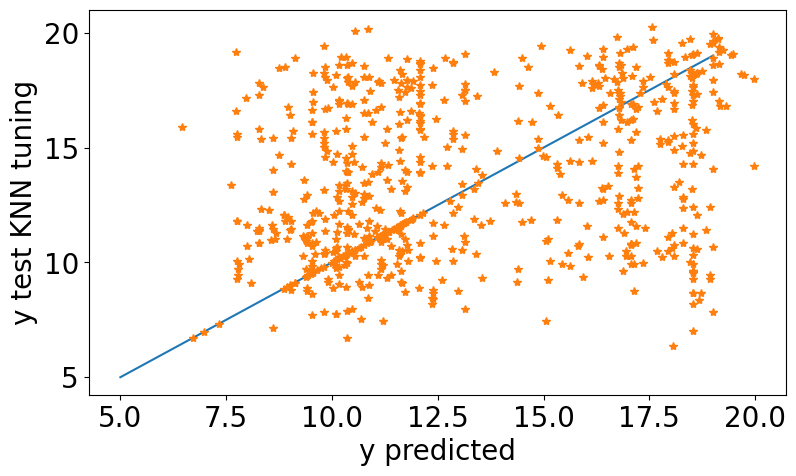

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X_train_KNN_tun, X_test_KNN_tun, y_train_KNN_tun, y_test_KNN_tun = train_test_split(X_train_KNN, y_train_KNN, random_state=42)
X_train_KNN_tun, X_test_KNN_tun, _ = Mutual_info(X_train_KNN_tun , y_train_KNN_tun, X_test_KNN_tun, 100)

KNN = KNeighborsRegressor(n_neighbors=1, p=2)
KNN.fit(X_train_KNN_tun, y_train_KNN_tun)
y_pred = KNN.predict(X_test_KNN_tun)
print("R squared score: ",KNN.score(X_test_KNN_tun, y_test_KNN_tun))

plt.rc("font", size=20)
plt.figure(figsize=(9,5))
plt.plot(range(int(min(y_pred))-1, int(max(y_pred))+1), range(int(min(y_pred))-1, int(max(y_pred))+1), label="y predict")
plt.plot( y_pred,y_test_KNN_tun, "*")
plt.xlabel("y predicted")
plt.ylabel("y test KNN tuning")

X_train_KNN_tun, X_test_KNN_tun, y_train_KNN_tun, y_test_KNN_tun = train_test_split(X_train_KNN, y_train_KNN, random_state=42)


In [ ]:
#select K best
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from matplotlib import pyplot
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
import sklearn
from sklearn.model_selection import GridSearchCV, KFold


def Mutual_info(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(mutual_info_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(mutual_info_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs


def evalParam(methods, param, list_X, y, cv):

    nb_nb_features = len(list_X)
    score = [[] for i in list_X]


    y = np.array(y)
    for i in range(nb_nb_features):
        list_X[i] = np.array(list_X[i])
        for j in range(len(methods)):
            score[i].append(np.zeros(len(param[j])))
            

    kf = KFold(n_splits=cv,random_state=42, shuffle=True)
    
    counter = 0
    for train_index, test_index in kf.split(list_X[0]):
        print(str(counter+1)+ " folds begon out of "+str(cv))
        counter +=1
        for i in range(nb_nb_features):
            
            X_arr = list_X[i]
            y_arr = y      
        
            X_train, X_test = X_arr[train_index, :], X_arr[test_index, :]
            y_train, y_test = y_arr[train_index].ravel(), y_arr[test_index].ravel()
            # .ravel() transforms any ND-array into a 1D-array

            scaler = StandardScaler()
            scaler.fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)

            for meth in range(len(methods)):
                for p in range(len(param[meth])):

                    method = sklearn.base.clone(methods[meth])
                    method.set_params(**param[meth][p])
                    method.fit(X_train, y_train)
                    y_pred = method.predict(X_test)
                    
                    score[i][meth][p] += np.sqrt(mean_squared_error(np.exp(y_test),np.exp(y_pred)))/cv
    return score


In [ ]:
#  Choose the number of features to keep

features_list = [500,  20, 10,  5, 4, 3, 2]
features_list = sorted(features_list, reverse=True)

liste_Xtrain = []
liste_Xtest = []

X_train_nonlin = X_train_KNN_tun
X_test_nonlin = X_test_KNN_tun

for i in range(len(features_list)):
    print(features_list[i])
    X_train_nonlin, X_test_nonlin, _ = Mutual_info(X_train_nonlin , y_train_KNN_tun, X_test_nonlin, features_list[i])
    liste_Xtrain.append( X_train_nonlin)
    liste_Xtest.append(X_test_nonlin)

features_list.insert(0, 2500)
liste_Xtrain.insert(0, X_train_KNN_tun)
liste_Xtest.insert(0, X_test_KNN_tun)

500
20
10
5
4
3
2


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

KNN=KNeighborsRegressor()
paramKNN=[{"n_neighbors":i ,"weights":j,"p":p}  for i in  [1, 4, 5, 6, 8, 9, 15] for j in ("uniform","distance")  for p in (1,2)] 

cv = 5
cv_scores = evalParam([KNN], [paramKNN], liste_Xtrain, y_train_KNN_tun, cv)
cv_scores_knn = cv_scores[0]


1 folds begon out of 5
2 folds begon out of 5


nb of features = 2500
{'n_neighbors': 6, 'weights': 'distance', 'p': 1} with score 69.98 Millions
nb of features = 500
{'n_neighbors': 6, 'weights': 'distance', 'p': 1} with score 70.19 Millions
nb of features = 20
{'n_neighbors': 4, 'weights': 'distance', 'p': 1} with score 63.28 Millions
nb of features = 10
{'n_neighbors': 4, 'weights': 'distance', 'p': 1} with score 61.03 Millions
nb of features = 5
{'n_neighbors': 4, 'weights': 'distance', 'p': 1} with score 60.81 Millions
nb of features = 4
{'n_neighbors': 4, 'weights': 'distance', 'p': 1} with score 59.98 Millions
nb of features = 3
{'n_neighbors': 5, 'weights': 'uniform', 'p': 1} with score 61.09 Millions
nb of features = 2
{'n_neighbors': 4, 'weights': 'uniform', 'p': 1} with score 61.99 Millions


Text(0, 0.5, 'square root of mean square error in millions euros')

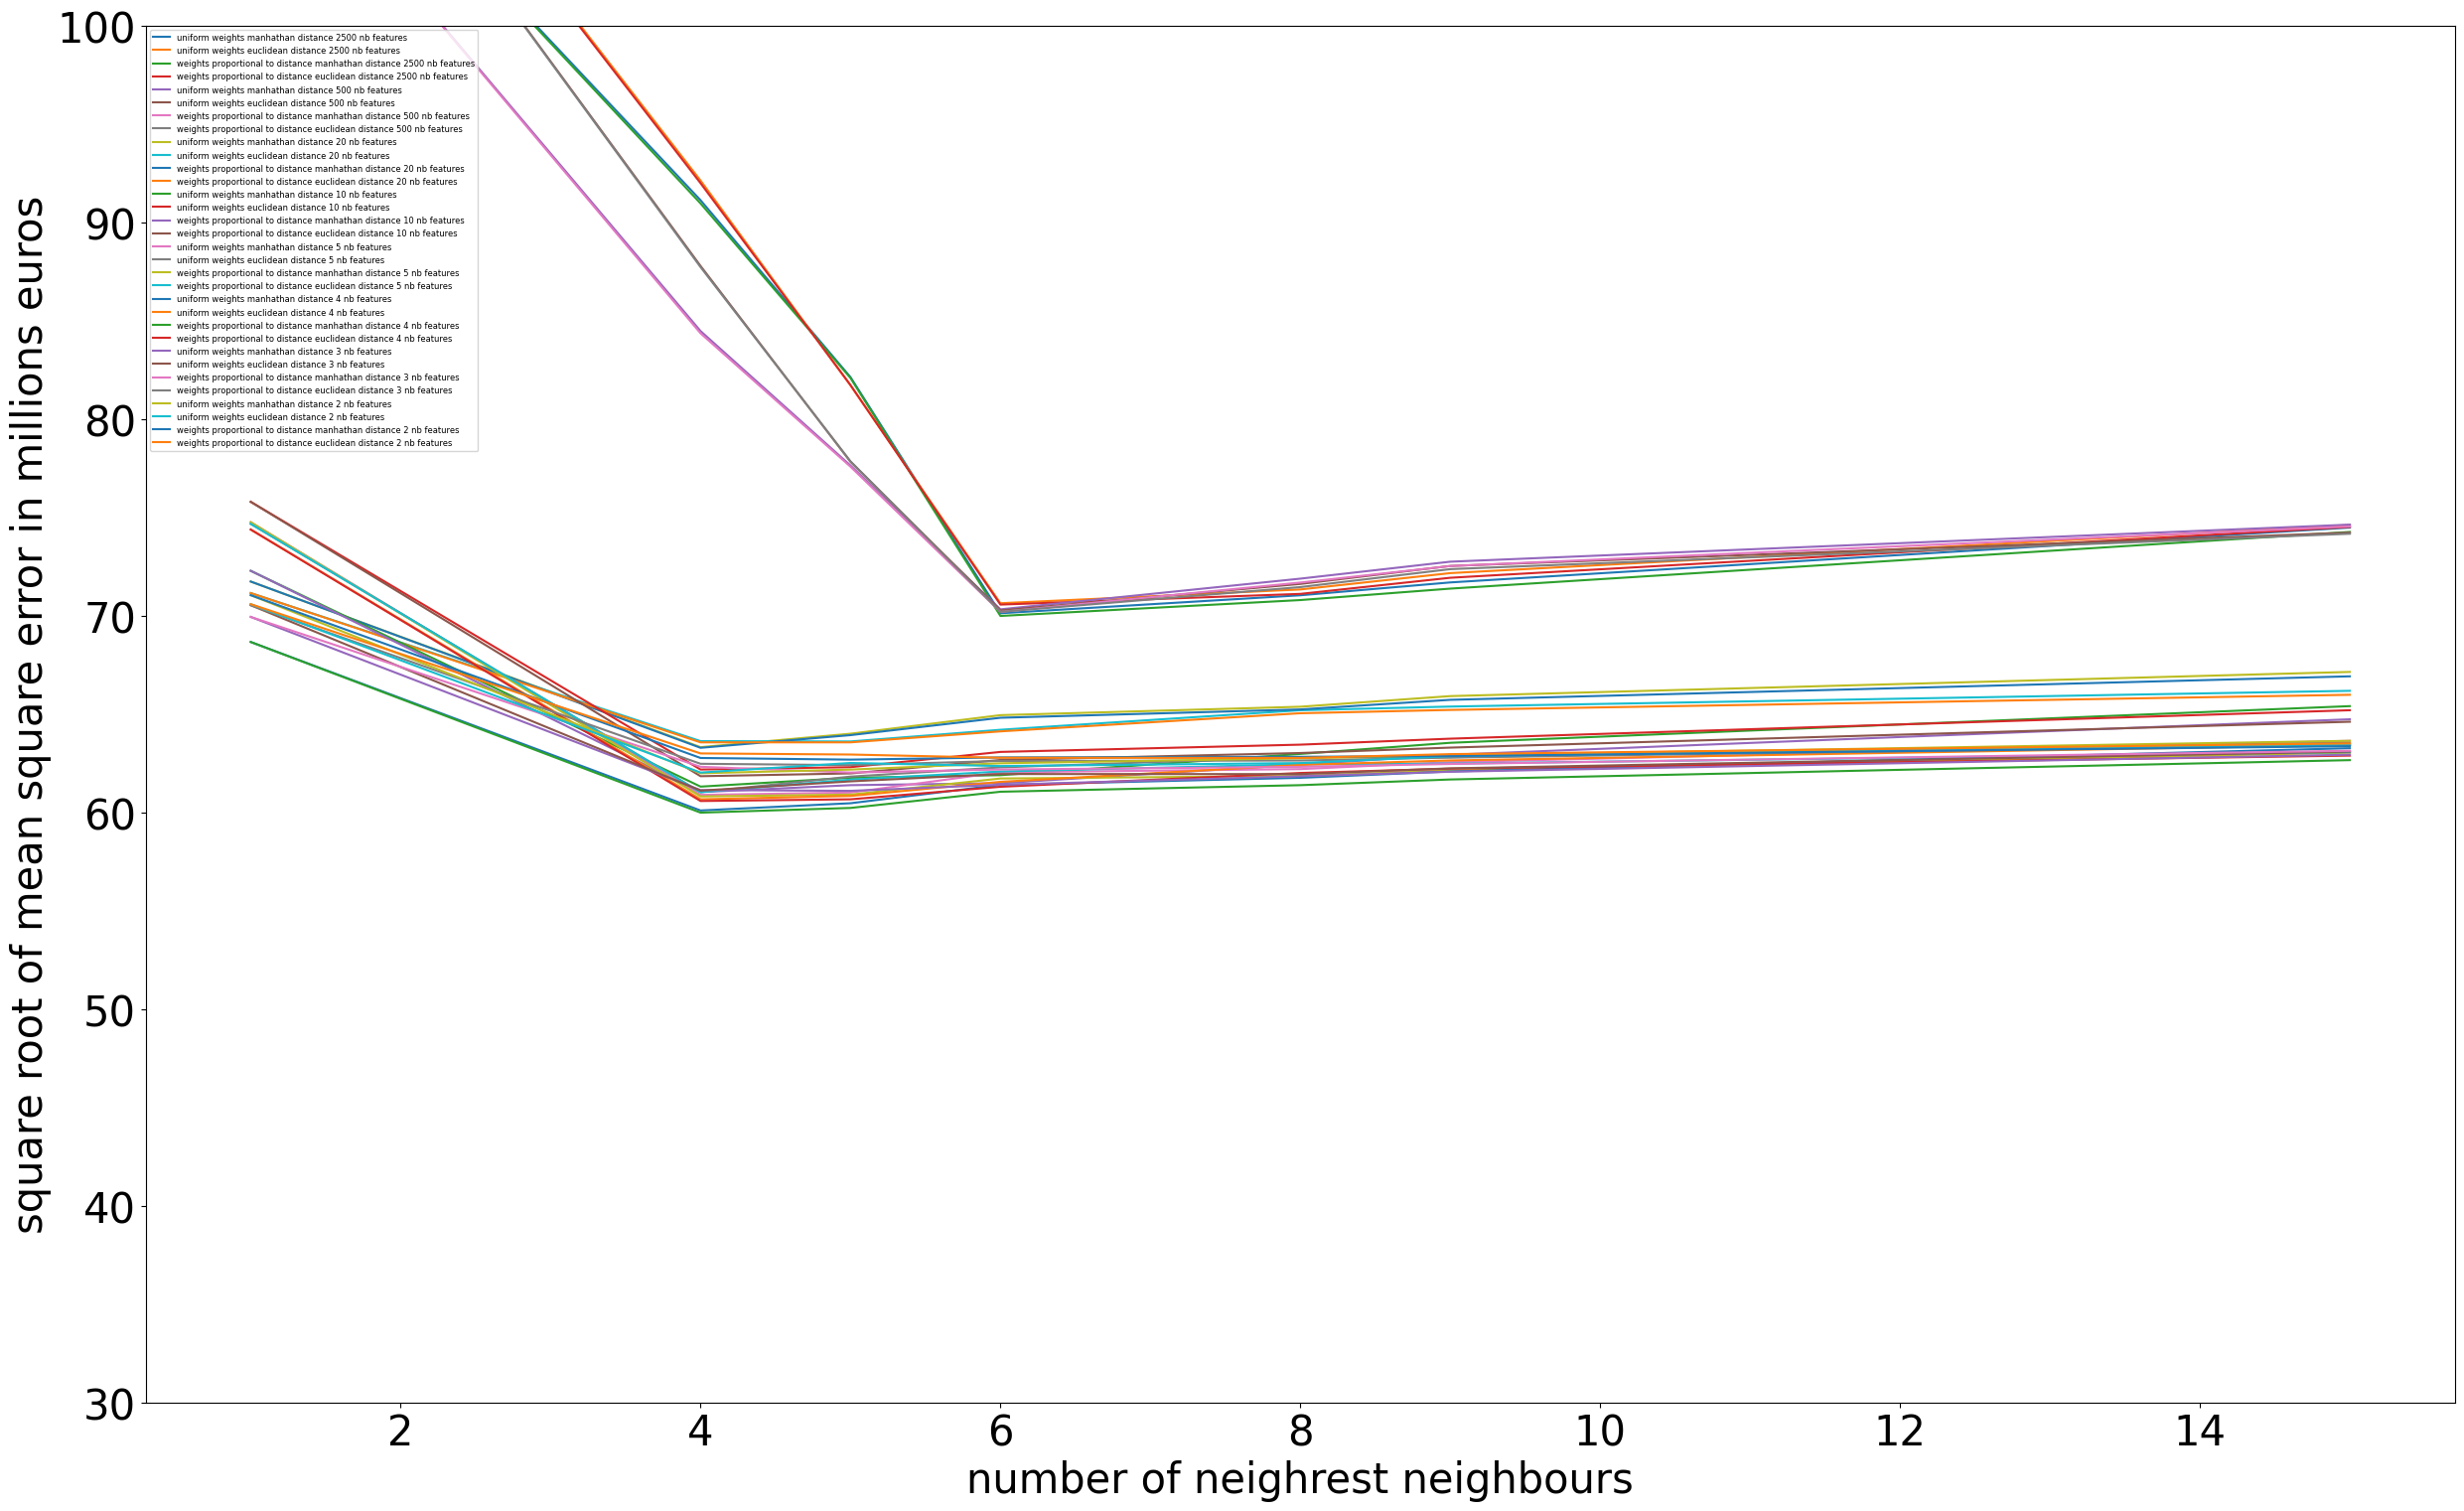

In [ ]:
import matplotlib.pyplot as plt


plt.rc("font", size=30)
plt.figure(figsize=(30,18))


list_best_parameters_knn = []
list_scores_best = []


for i in range(len(features_list)):

    cv_scores_knn = cv_scores[i]
    nb_features = features_list[i]

    KNNbest =list(cv_scores_knn[0]).index(min(cv_scores_knn[0]))  # to do
    print("nb of features = " +str(nb_features))
    print(paramKNN[KNNbest], "with score {0:.2f} Millions".format(cv_scores_knn[0][KNNbest]/1000000))
    list_best_parameters_knn.append(KNNbest)
    list_scores_best.append(cv_scores_knn[0][KNNbest])


    # paramKNN=[{"n_neighbors":i ,"weights":j,"p":p} for i in np.arange(1, 100, 9)  for j in ("uniform","distance")  for p in (1,2,100)] 
    # uniform distance 
    uniform1  = [index for index,value in enumerate(paramKNN)  if (value['weights'] == "uniform") and (value['p']==1)]
    uniform2  = [index for index,value in enumerate(paramKNN)  if (value['weights'] == "uniform") and (value['p']==2)]

    distance1 =  [index for index,value in enumerate(paramKNN)  if (value['weights'] == "distance") and (value['p']==1)]
    distance2 =  [index for index,value in enumerate(paramKNN)  if (value['weights'] == "distance") and (value['p']==2)]
    # print(uniform)

    n_neigbours = [value['n_neighbors'] for index,value in enumerate(paramKNN)  if (value['weights'] == "distance") and (value['p']==1)]


    # F-score of KNN 
    plt.plot(n_neigbours, cv_scores_knn[0][uniform1]/1000000, label="uniform weights manhathan distance "+str(nb_features)+" nb features")
    plt.plot(n_neigbours, cv_scores_knn[0][uniform2]/1000000, label="uniform weights euclidean distance "+str(nb_features)+" nb features")


    plt.plot(n_neigbours, cv_scores_knn[0][distance1]/1000000, label="weights proportional to distance manhathan distance "+str(nb_features)+" nb features")
    plt.plot(n_neigbours, cv_scores_knn[0][distance2]/1000000, label="weights proportional to distance euclidean distance "+str(nb_features)+" nb features")

    # plt.plot(n_neigbours, np.ones(len(n_neigbours))*cv_scores[0][0], label="F-score of the Linear Regression")


    # print([cv_scores[1][i]for i in distance])


plt.ylim([30, 100])
plt.legend(loc=2, prop={'size': 6})

plt.xlabel('number of neighrest neighbours')
plt.ylabel('square root of mean square error in millions euros')


In [ ]:
minimum = min(list_scores_best)
index_best = list_scores_best.index(minimum)
KNNbest = list_best_parameters_knn[index_best]
best_nb_features = features_list[index_best]


KNNbest =list(cv_scores_knn[0]).index(min(cv_scores_knn[0]))  # to do
print("nb of features = " +str(best_nb_features))
print(paramKNN[KNNbest], "with score {0:.2f} Millions".format(minimum/1000000))

nb of features = 4
{'n_neighbors': 4, 'weights': 'uniform', 'p': 1} with score 59.98 Millions


Mean square error in millions : 54.30110815400391
R squared score:  0.5479246177890762


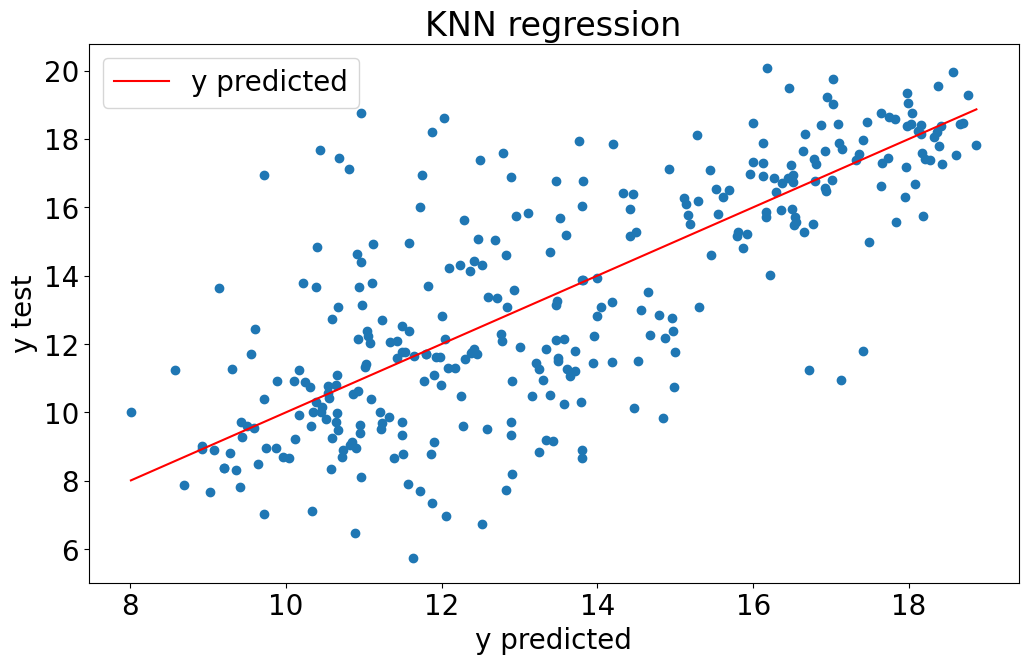

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn_regressor = KNeighborsRegressor(**paramKNN[KNNbest])

X_train_KNN, X_test_KNN, _ = Mutual_info(X_train_KNN , y_train_KNN, X_test_KNN, best_nb_features)

knn_regressor.fit(X_train_KNN, y_train_KNN)
y_predict = knn_regressor.predict(X_test_KNN)

plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('KNN regression')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(y_predict,y_test_KNN,'o')
plt.plot(np.linspace(np.min(y_predict),np.max(y_predict),2),np.linspace(np.min(y_predict),np.max(y_predict),2), label="y predicted", color="red")
plt.legend()

y_test1= np.exp(y_test_KNN)
y_predict1 = np.exp(y_predict)

print("Mean square error in millions :", np.sqrt(mean_squared_error(y_test1,y_predict1))/1000000)
print("R squared score: ",knn_regressor.score(X_test_KNN, y_test_KNN))


#### 3. Support Vector Regression

In [ ]:
X_train_SVR = X_train_models.copy()
X_test_SVR =  X_test_models.copy()
y_train_SVR = y_train_models.copy()
y_test_SVR = y_test_models.copy() 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_SVR)
X_train_SVR = scaler.transform(X_train_SVR)
X_test_SVR = scaler.transform(X_test_SVR)

In [ ]:
y_train_SVR = y_train_SVR["log_revenue"]
y_test_SVR = y_test_SVR["log_revenue"]

In [ ]:
#select K best
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from matplotlib import pyplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold


def Mutual_info(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(mutual_info_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(mutual_info_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs


In [ ]:
X_train_SVR_tun, X_test_SVR_tun, y_train_SVR_tun, y_test_SVR_tun = train_test_split(X_train_SVR, y_train_SVR, random_state=42)


In [ ]:
# Fit the model over the training datafrom sklearn.svm import SVR
from sklearn.svm import  SVR

features_list = [3, 4, 5, 10, 50, 100, 1000]
list_C = np.logspace(-2, 3, 16)
list_gamma = np.logspace(-2, 2, 13)

errors_list = [[]for i in list_C]

X_train_SVR_tun4,  X_test_SVR_tun4, _ = Mutual_info(X_train_SVR_tun, y_train_SVR_tun, X_test_SVR_tun, 4)


for i in range(len(list_C)):
    C=list_C[i]
    for j in range(len(list_gamma)):
        gamma = list_gamma[j]  

        regressor = SVR(kernel = 'rbf', C=C, gamma=gamma)
        regressor.fit(X_train_SVR_tun4, y_train_SVR_tun)
        y_predict = regressor.predict(X_test_SVR_tun4)

        MSE = np.sqrt(mean_squared_error(np.exp(y_test_SVR_tun),np.exp(y_predict)))
        errors_list[i].append(MSE)

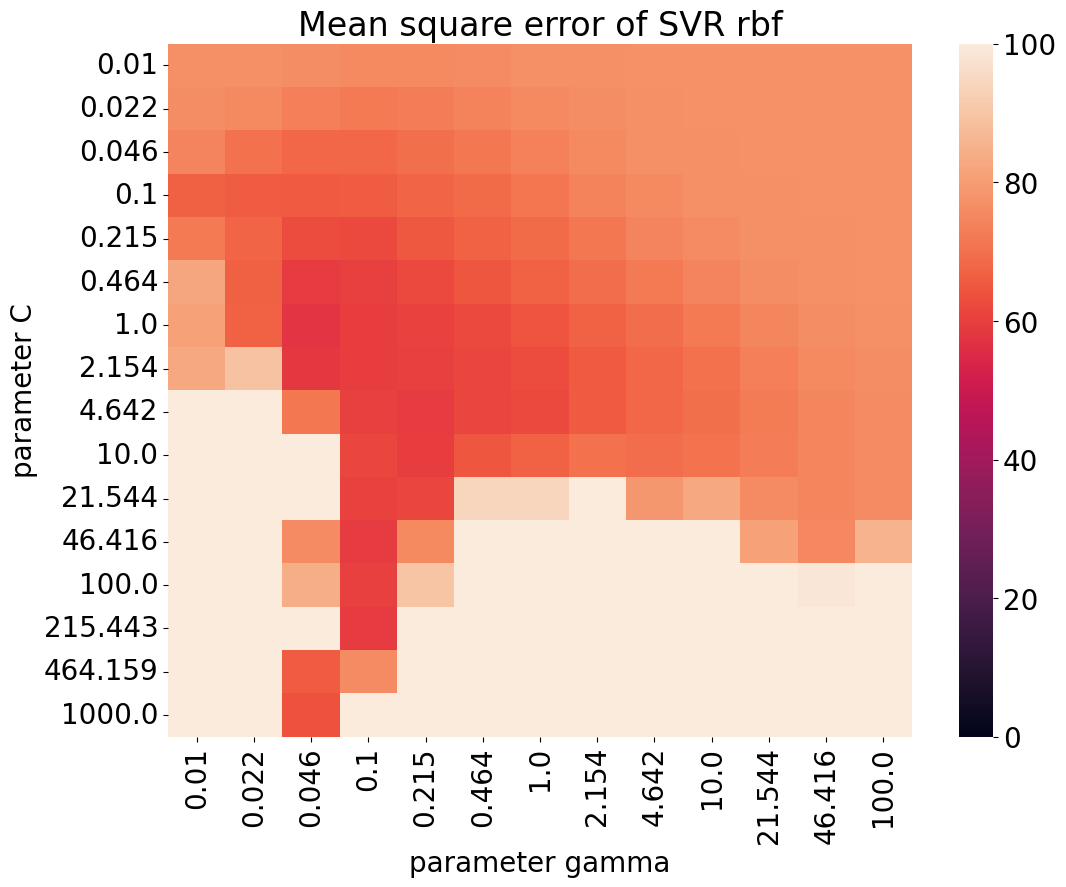

In [ ]:
fig = plt.figure(figsize=(12,9), facecolor="w")
sns.heatmap(np.array(errors_list)/1000000,  vmin=0, vmax=100, fmt='.2g', yticklabels=np.round(list_C, 3), xticklabels=np.round(list_gamma, 3))

plt.ylabel("parameter C")
plt.xlabel("parameter gamma")
plt.title("Mean square error of SVR rbf")
# fig.add_axes(ax)
plt.show()
# fig.savefig("heatmap_"+str(features_list_plot[i])+"_features.png", dpi=400)


C = 1.0
gamma = 0.046415888336127774
Mean square error in millions : 48.12721087221502
R squared score:  0.5759134269625845


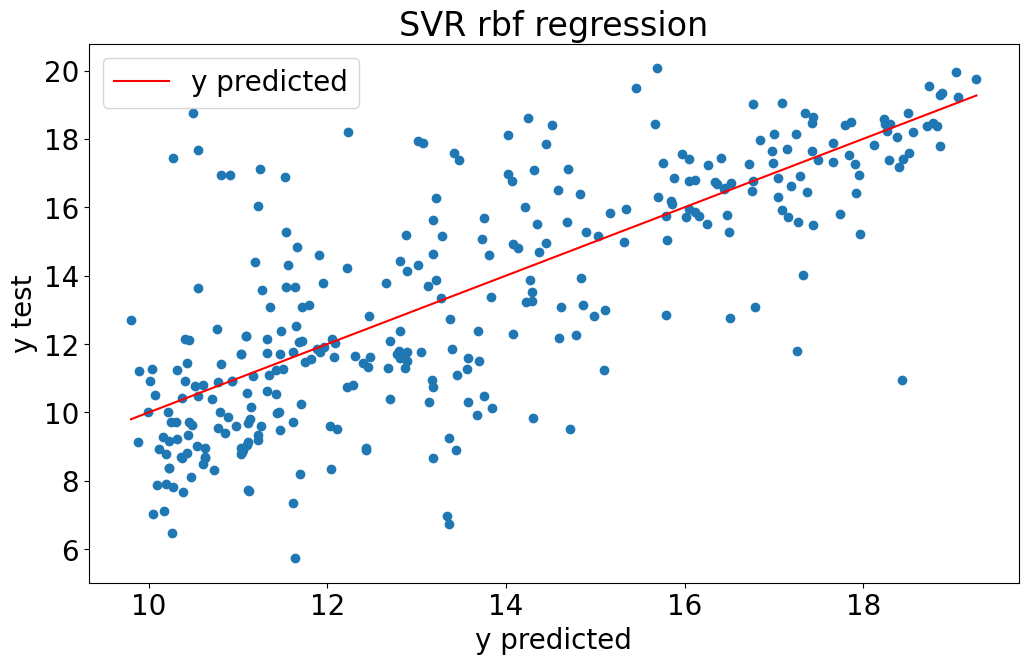

In [ ]:
errors_list_a = np.array(errors_list)
min_error = np.min(errors_list_a)


for i in range(len(errors_list_a)):
    for j in range(len(errors_list_a[0])):
        if errors_list_a[i][j] == min_error:
            C = list_C[i]
            gamma = list_gamma[j]
            break

print("C = "+str(C))
print("gamma = "+str(gamma))



from sklearn.svm import  SVR

X_train_SVR4,  X_test_SVR4, _ = Mutual_info(X_train_SVR, y_train_SVR, X_test_SVR, 4)


regressor = SVR(kernel = 'rbf', C=C, gamma=gamma)
regressor.fit(X_train_SVR4, y_train_SVR)
y_predict = regressor.predict(X_test_SVR4)


plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('SVR rbf regression')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(y_predict,y_test_SVR,'o')
plt.plot(np.linspace(np.min(y_predict),np.max(y_predict),2),np.linspace(np.min(y_predict),np.max(y_predict),2), label="y predicted", color="red")
plt.legend()

y_test1= np.exp(y_test_SVR)
y_predict1 = np.exp(y_predict)

print("Mean square error in millions :", np.sqrt(mean_squared_error(y_test1,y_predict1))/1000000)
print("R squared score: ",regressor.score(X_test_SVR4, y_test_SVR))


## 3) Choose Model

results for our predictors:

- **mean** :
  - *sqrt(Mean Square Error)* : 61.47 Millions
  - *R²* : -1.18
- **linear regression** :
  - *sqrt(Mean Square Error)* : 61.39 Millions
  - *R²* : 0.38
- **MLP regression** : 
  - *sqrt(Mean Square Error)* : 87.34 Millions
  - *R²* : 0.19 <br>
(! changes a little bit at every execution)
- **KNN regression** : 
  - *sqrt(Mean Square Error)* : 54.3 Millions
  - *R²* : 0.55
- **SVR rbf** : 
  - *sqrt(Mean Square Error)* : 48.13 Millions
  - *R²* : 0.58

For our final predictor we choose **KNN Regression** to be our method. <br>
- Even if it is not the most efficient now (best R² but not the best MSE), it is the one who has the better chance of improving the result with more data 